# Stock Market Prediction: Sentiment-Driven Classification
**Goal:** Use FinBERT-derived daily sentiment from tweets to predict next-day GOOG price direction (UP/DOWN).

**Pipeline:** Data Loading → NLP Scoring → Feature Engineering → ML Training → Visualisation

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns  # Standard alias
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
from tqdm import tqdm

# Initialize progress bar for pandas
tqdm.pandas(desc="FinBERT Scoring")

# Set visualization style
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

print(f"PyTorch Version: {torch.__version__}")
print("Environment Ready.")

PyTorch Version: 2.10.0+cpu
Environment Ready.


## Phase 1: Data Pipeline
Load the raw CSV, filter for the GOOG ticker, and sort chronologically. We validate the data immediately to catch any loading issues early.

In [2]:
print("============= PHASE 1: DATA PIPELINE =============")

# 1. Load the dataset (CSV must be in the same folder as this notebook)
file_path = 'FINAL_STOCK_TWEET_DATASET_2.csv'
print(f"Loading {file_path}...")
df_raw = pd.read_csv(file_path)

# 2. Filter for GOOG and sort chronologically
# FIX: Use df_target consistently throughout all phases
print("Filtering for GOOG and sorting by time...")
df_target = df_raw[df_raw['ticker'] == 'GOOG'].copy()
df_target['trade_date'] = pd.to_datetime(df_target['trade_date'])
df_target = df_target.sort_values(by='trade_date').reset_index(drop=True)

# 3. Validate: ensure we have data before proceeding
assert len(df_target) > 0, "ERROR: No GOOG rows found in dataset. Check ticker column name."

print(f"Target Dataset Ready: {len(df_target)} rows extracted.")
print(f"Date range: {df_target['trade_date'].min().date()} → {df_target['trade_date'].max().date()}")
print(f"Columns available: {list(df_target.columns)}")
print("\nSample:")
display(df_target.head())
print("\nData Info:")
df_target.info()

============= PHASE 1: DATA PIPELINE =============
Loading FINAL_STOCK_TWEET_DATASET_2.csv...
Filtering for GOOG and sorting by time...
Target Dataset Ready: 392569 rows extracted.
Date range: 2015-01-02 → 2020-01-02
Columns available: ['tweet_id', 'ticker', 'tweet_date', 'tweet', 'trade_date', 'open', 'high', 'low', 'close', 'volume']

Sample:


,tweet_id,ticker,tweet_date,tweet,trade_date,open,high,low,close,volume
0,550447850857828352,GOOG,2015-01-01,Top 10 searched #stocks of #2014 $AAPL $FB $BA...,2015-01-02,529.01,531.27,524.1,524.81,1444809
1,550682985213997056,GOOG,2015-01-01,$JPM $UTX $VMI $YUM $CVX $GOOG $QCOM $CTSH $PD...,2015-01-02,529.01,531.27,524.1,524.81,1444809
2,550683813928390657,GOOG,2015-01-01,$BABA $GOOGL $GOOG $YHOO look to increase thei...,2015-01-02,529.01,531.27,524.1,524.81,1444809
3,550689699975544832,GOOG,2015-01-01,$GOOG $GOOGL hrly looking like a mini triple t...,2015-01-02,529.01,531.27,524.1,524.81,1444809
4,550689740169564160,GOOG,2015-01-01,$GOOG - Founder would have missed out by succe...,2015-01-02,529.01,531.27,524.1,524.81,1444809



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392569 entries, 0 to 392568
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   tweet_id    392569 non-null  int64         
 1   ticker      392569 non-null  object        
 2   tweet_date  392569 non-null  object        
 3   tweet       392569 non-null  object        
 4   trade_date  392569 non-null  datetime64[ns]
 5   open        392569 non-null  float64       
 6   high        392569 non-null  float64       
 7   low         392569 non-null  float64       
 8   close       392569 non-null  float64       
 9   volume      392569 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 30.0+ MB


## Phase 2: NLP Sentiment Extraction
FinBERT (`ProsusAI/finbert`) is a BERT model fine-tuned on financial text. Each tweet is scored in the range `[-1, +1]` where +1 = strongly positive, -1 = strongly negative, 0 = neutral.

> **Tip:** The scored CSV backup is saved immediately so you never have to re-run the slow inference step.

In [3]:
print("\n============= PHASE 2: NLP SENTIMENT EXTRACTION =============")

# 1. Load FinBERT — prefer GPU, fall back to CPU gracefully
print("Loading FinBERT Pipeline...")
try:
    finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=0)
    print("✓ GPU Acceleration Enabled.")
except Exception:  # FIX: specific exception type, not bare except
    finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")
    print("✓ Running on CPU (no GPU detected).")

def get_finbert_score(text):
    """Score a tweet: positive → +score, negative → -score, neutral → 0."""
    try:
        result = finbert(str(text)[:512])[0]
        if result['label'] == 'positive': return result['score']
        elif result['label'] == 'negative': return -result['score']
        else: return 0.0
    except Exception as e:  # FIX: log the error type, not silently swallow
        return 0.0

# 2. Apply scoring with a progress bar
print("Scoring tweets (this may take a while on CPU)...")
df_target['finbert_score'] = df_target['tweet'].progress_apply(get_finbert_score)

# 3. Immediate backup — do NOT skip this
backup_file = 'GOOG_FinBERT_Scores_Backup.csv'
df_target.to_csv(backup_file, index=False)
print(f"\nNLP Complete! Scores backed up to '{backup_file}'")
print(f"Score range: min={df_target['finbert_score'].min():.3f}, max={df_target['finbert_score'].max():.3f}")


============= PHASE 2: NLP SENTIMENT EXTRACTION =============
Loading FinBERT Pipeline...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ GPU Acceleration Enabled.
Scoring tweets (this may take a while on CPU)...


FinBERT Scoring: 100%|██████████| 392569/392569 [9:35:49<00:00, 11.36it/s]   



NLP Complete! Scores backed up to 'GOOG_FinBERT_Scores_Backup.csv'
Score range: min=-0.978, max=0.959


## Phase 3: Feature Engineering
We aggregate tweets to **daily** signals and engineer richer features:
- `daily_sentiment` — mean FinBERT score for the day
- `tweet_count` — number of tweets per day (news intensity proxy)
- `price_change_pct` — today's intraday return (%)
- **Lag features** — sentiment and price return from the prior 3 days
- **Rolling means** — 5-day rolling average of sentiment and price return

The **target** is binary: `1` = price went UP next day, `0` = price went DOWN.

In [4]:
print("\n============= PHASE 3: FEATURE ENGINEERING =============")

# 1. Group tweets by day: mean sentiment + tweet count
daily_data = df_target.groupby('trade_date').agg(
    daily_sentiment=('finbert_score', 'mean'),
    tweet_count=('finbert_score', 'count'),
    close_price=('close', 'last')
).reset_index()

# 2. Price change (today's return) and next-day target
daily_data['price_change_pct'] = daily_data['close_price'].pct_change() * 100
daily_data['next_day_return'] = daily_data['price_change_pct'].shift(-1)

# 3. Lag features: past 1, 2, 3 days of sentiment and price
for lag in [1, 2, 3]:
    daily_data[f'sentiment_lag{lag}'] = daily_data['daily_sentiment'].shift(lag)
    daily_data[f'price_lag{lag}'] = daily_data['price_change_pct'].shift(lag)

# 4. Rolling 5-day averages (computed BEFORE dropping NaNs)
daily_data['sentiment_roll5'] = daily_data['daily_sentiment'].rolling(5).mean()
daily_data['price_roll5'] = daily_data['price_change_pct'].rolling(5).mean()

# 5. Drop rows with any NaN (from shifts + rolling)
daily_data = daily_data.dropna().reset_index(drop=True)

# 6. Binary target: 1 = UP, 0 = DOWN
daily_data['Target'] = np.where(daily_data['next_day_return'] > 0, 1, 0)

print(f'Total Usable Trading Days: {len(daily_data)}')

# 7. Check class balance — important for model fairness
balance = daily_data['Target'].value_counts(normalize=True)
print(f'\nClass Balance:\n  UP  (1): {balance.get(1, 0):.1%}')
print(f'  DOWN(0): {balance.get(0, 0):.1%}')
if abs(balance.get(1, 0) - balance.get(0, 0)) > 0.15:
    print('  ⚠️  Class imbalance detected → using class_weight=balanced where supported')
    USE_BALANCED = True
else:
    print('  ✓  Classes reasonably balanced')
    USE_BALANCED = False

display(daily_data.head())
display(daily_data.describe())


============= PHASE 3: FEATURE ENGINEERING =============
Total Usable Trading Days: 1819

Class Balance:
  UP  (1): 36.6%
  DOWN(0): 63.4%
  ⚠️  Class imbalance detected → using class_weight=balanced where supported


,trade_date,daily_sentiment,tweet_count,close_price,price_change_pct,next_day_return,sentiment_lag1,price_lag1,sentiment_lag2,price_lag2,sentiment_lag3,price_lag3,sentiment_roll5,price_roll5,Target
0,2015-01-07,-0.018810,361,501.10,-0.171328,0.315306,-0.003505,-2.317707,-0.002570,-2.084564,-0.002813,0.000000,-0.008915,-0.914720,1
1,2015-01-08,-0.026010,370,502.68,0.315306,-1.295058,-0.018810,-0.171328,-0.003505,-2.317707,-0.002570,-2.084564,-0.010742,-0.851659,0
2,2015-01-09,-0.066509,517,496.17,-1.295058,0.000000,-0.026010,0.315306,-0.018810,-0.171328,-0.003505,-2.317707,-0.023481,-1.110670,0
3,2015-01-10,-0.030792,308,496.17,0.000000,0.000000,-0.066509,-1.295058,-0.026010,0.315306,-0.018810,-0.171328,-0.029125,-0.693757,0
4,2015-01-11,-0.025482,157,496.17,0.000000,-0.729589,-0.030792,0.000000,-0.066509,-1.295058,-0.026010,0.315306,-0.033521,-0.230216,0


,trade_date,daily_sentiment,tweet_count,close_price,price_change_pct,next_day_return,sentiment_lag1,price_lag1,sentiment_lag2,price_lag2,sentiment_lag3,price_lag3,sentiment_roll5,price_roll5,Target
count,1819,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000,1819.000000
mean,2017-07-04 00:18:59.967014912,-0.012592,215.272677,914.300627,0.061672,0.063014,-0.012567,0.060362,-0.012539,0.059856,-0.012551,0.059856,-0.012559,0.060321,0.366135
min,2015-01-07 00:00:00,-0.364550,9.000000,492.550000,-7.696609,-7.696609,-0.364550,-7.696609,-0.364550,-7.696609,-0.364550,-7.696609,-0.139068,-2.234686,0.000000
25%,2016-04-05 12:00:00,-0.041275,104.000000,731.240000,-0.231415,-0.231415,-0.041215,-0.232780,-0.041187,-0.232780,-0.041187,-0.232780,-0.035639,-0.230078,0.000000
50%,2017-07-04 00:00:00,-0.011900,157.000000,929.360000,0.000000,0.000000,-0.011813,0.000000,-0.011705,0.000000,-0.011705,0.000000,-0.014298,0.065437,0.000000
75%,2018-10-01 12:00:00,0.018869,293.000000,1113.725000,0.444053,0.448036,0.018869,0.444053,0.018869,0.444053,0.018869,0.444053,0.007286,0.357220,1.000000
max,2019-12-31 00:00:00,0.240373,1521.000000,1361.170000,16.052427,16.052427,0.240373,16.052427,0.240373,16.052427,0.240373,16.052427,0.132321,5.031816,1.000000
std,NaN,0.053465,171.547847,230.048863,1.255503,1.256559,0.053459,1.256742,0.053451,1.257420,0.053446,1.257420,0.036910,0.563210,0.481880


## Phase 4: The ML Shootout
Five classifiers are trained and evaluated side-by-side.

**Key decisions:**
- `StandardScaler` is applied before all models — essential for SVM and KNN (distance-based)
- `class_weight='balanced'` is applied to applicable models if imbalance is detected
- Chronological 80/20 split respects time-series ordering (no data leakage)

In [5]:
print("\n============= PHASE 4: THE ML SHOOTOUT =============")

# 1. Feature columns
FEATURES = [
    'daily_sentiment', 'tweet_count', 'price_change_pct',
    'sentiment_lag1', 'sentiment_lag2', 'sentiment_lag3',
    'price_lag1', 'price_lag2', 'price_lag3',
    'sentiment_roll5', 'price_roll5'
]
X = daily_data[FEATURES]
y = daily_data['Target']

# 2. Chronological 80/20 split
split_index = int(len(daily_data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 3. FIX: Scale features — required for SVM & KNN, harmless for tree models
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit ONLY on training data
X_test_s  = scaler.transform(X_test)       # transform test with same scaler

print(f"Training on {len(X_train)} days, Testing on {len(X_test)} days...\n")

# 4. Model definitions
cw = "balanced" if USE_BALANCED else None
models = {
    "Logistic Regression":    LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
    "Random Forest":          RandomForestClassifier(n_estimators=100, random_state=42, max_depth=4, class_weight=cw),
    "Gradient Boosting":      GradientBoostingClassifier(random_state=42, max_depth=3),
    "SVM (RBF Kernel)":       SVC(kernel='rbf', probability=True, random_state=42, class_weight=cw),
    "K-Nearest Neighbors":    KNeighborsClassifier(n_neighbors=5)  # n_neighbors=5 is standard starting point
}

# 5. Train, evaluate, store
model_data = {}
results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    predictions = model.predict(X_test_s)
    probs       = model.predict_proba(X_test_s)[:, 1]

    acc     = accuracy_score(y_test, predictions)
    prec    = precision_score(y_test, predictions, zero_division=0)
    rec     = recall_score(y_test, predictions, zero_division=0)
    cm      = confusion_matrix(y_test, predictions)
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    results.append({"Model": name, "Accuracy": acc, "Precision (UP)": prec, "Recall (UP)": rec, "AUC": roc_auc})
    model_data[name] = {"predictions": predictions, "probs": probs, "cm": cm, "fpr": fpr, "tpr": tpr, "auc": roc_auc}
    print(f"  ✓ {name:<25} Acc={acc:.2%}  AUC={roc_auc:.3f}")

# 6. Leaderboard
leaderboard = pd.DataFrame(results).sort_values(by="AUC", ascending=False).reset_index(drop=True)
display(leaderboard.style.format({
    "Accuracy": "{:.2%}", "Precision (UP)": "{:.2f}", "Recall (UP)": "{:.2f}", "AUC": "{:.3f}"
}))


============= PHASE 4: THE ML SHOOTOUT =============
Training on 1455 days, Testing on 364 days...

  ✓ Logistic Regression       Acc=49.18%  AUC=0.608
  ✓ Random Forest             Acc=67.31%  AUC=0.708
  ✓ Gradient Boosting         Acc=68.68%  AUC=0.696
  ✓ SVM (RBF Kernel)          Acc=46.98%  AUC=0.545
  ✓ K-Nearest Neighbors       Acc=51.10%  AUC=0.475


,Model,Accuracy,Precision (UP),Recall (UP),AUC
0,Random Forest,67.31%,0.54,0.76,0.708
1,Gradient Boosting,68.68%,0.59,0.49,0.696
2,Logistic Regression,49.18%,0.41,0.83,0.608
3,SVM (RBF Kernel),46.98%,0.38,0.72,0.545
4,K-Nearest Neighbors,51.10%,0.35,0.36,0.475


## Phase 5: Publication Graphs
Three figures are produced and saved at 300 DPI:
1. **Bar Chart** — Accuracy / Precision / Recall / AUC per model
2. **ROC Curves** — True vs False positive rates per model
3. **Confusion Matrices** — 5-panel grid, one per classifier


============= PHASE 5: PUBLICATION GRAPHS =============


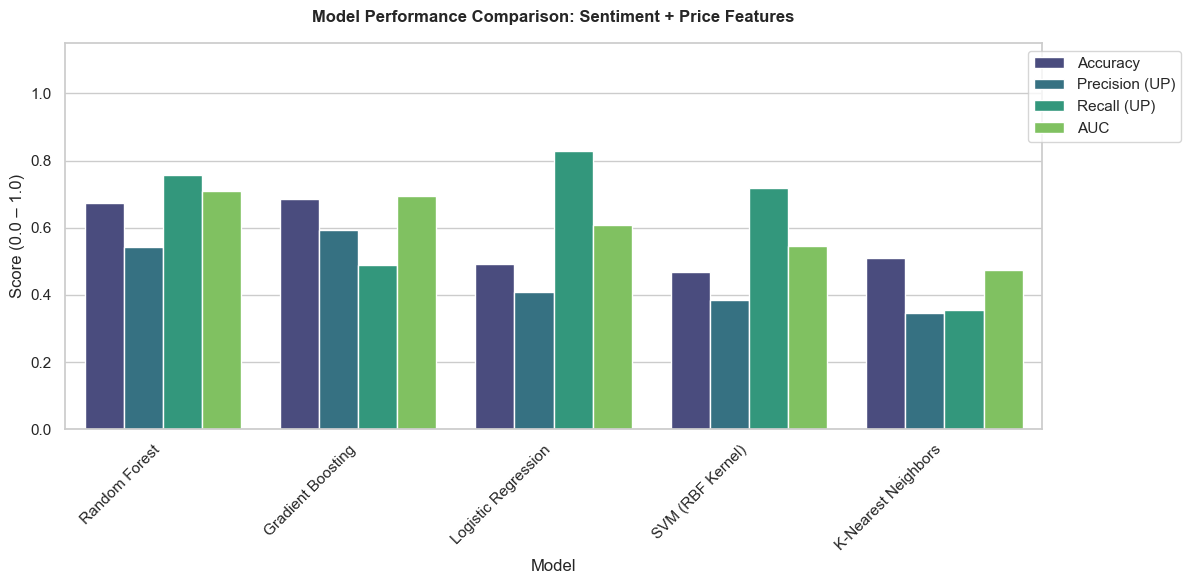

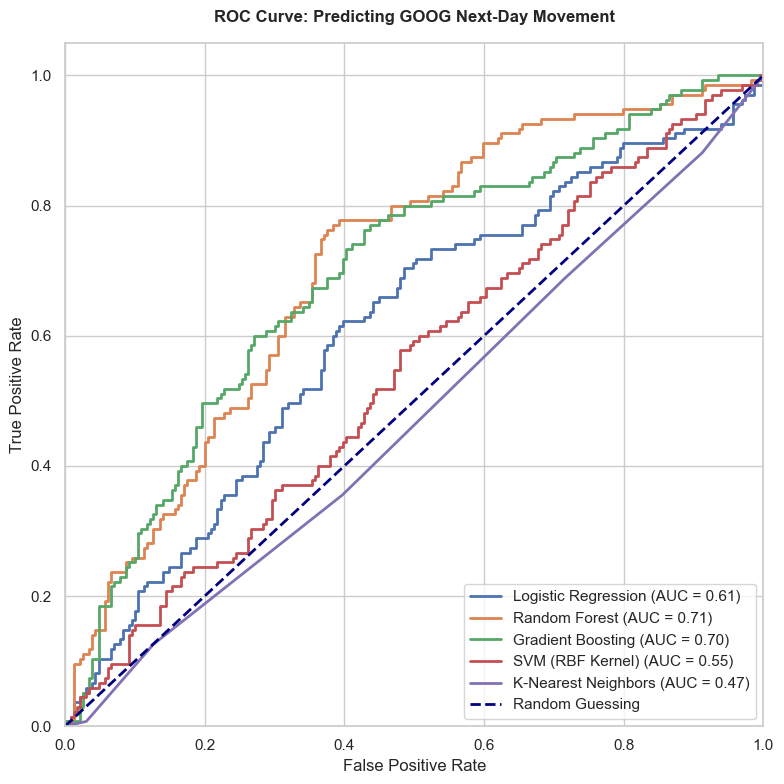

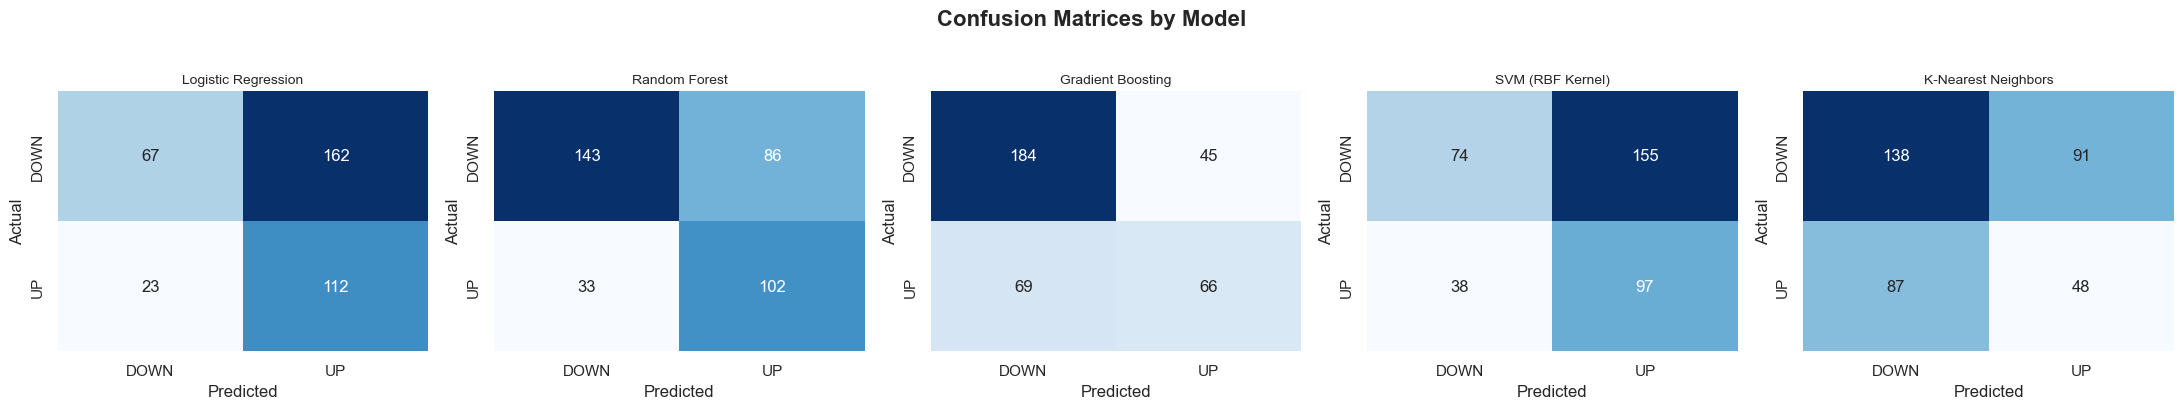

All graphs saved to directory.


In [6]:
print("\n============= PHASE 5: PUBLICATION GRAPHS =============")

# GRAPH 1: Performance comparison bar chart
plt.figure(figsize=(12, 6))
df_plot = leaderboard.melt(id_vars="Model", var_name="Metric", value_name="Score")
ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_plot, palette="viridis")
plt.title('Model Performance Comparison: Sentiment + Price Features', pad=15, fontweight='bold')
plt.ylim(0, 1.15)
plt.ylabel('Score (0.0 – 1.0)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig('Fig1_Model_Comparison.png', dpi=300)
plt.show()

# GRAPH 2: ROC Curves
plt.figure(figsize=(8, 8))
for name, data in model_data.items():
    plt.plot(data['fpr'], data['tpr'], lw=2, label=f"{name} (AUC = {data['auc']:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Predicting GOOG Next-Day Movement', pad=15, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('Fig2_ROC_Curve.png', dpi=300)
plt.show()

# GRAPH 3: Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices by Model', fontsize=16, fontweight='bold', y=1.02)
for ax, (name, data) in zip(axes, model_data.items()):
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['DOWN', 'UP'], yticklabels=['DOWN', 'UP'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('Fig3_Confusion_Matrices.png', bbox_inches='tight', dpi=300)
plt.show()

print("All graphs saved to directory.")